In [2]:
import sys
sys.path.append('../src')

import matplotlib.pyplot as plt
import torch
import numpy as np

# sbi specific imports
from sbi.analysis import pairplot
from sbi.inference import MNLE
from sbi.inference.posteriors import MCMCPosteriorParameters

# Import your DDM components
from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import DDMSimulator, create_ddm_prior

In [3]:
## DDM Model Setup
# Your 3-parameter DDM: [drift, gap, reward_pulse]
simulator = DDMSimulator()
prior = create_ddm_prior()

print("DDM Parameters:")
print("- drift: evidence accumulation rate")  
print("- gap: distance to decision boundary")
print("- reward_pulse: size of reward bumps")

DDM Parameters:
- drift: evidence accumulation rate
- gap: distance to decision boundary
- reward_pulse: size of reward bumps


In [ ]:
## Generate observed data
# Set a seed for reproducibility
seed = 0
torch.manual_seed(seed)
num_trials = 20  # Number of trials in our "experiment"

# Sample true parameters from prior (these are the "unknown" parameters we want to recover)
theta_o = prior.sample((1,))
print(f"\nTrue parameters: drift={theta_o[0,0]:.3f}, gap={theta_o[0,1]:.3f}, reward_pulse={theta_o[0,2]:.3f}")

# Generate observed data using these parameters
x_o = torch.stack([simulator(theta_o[0]) for _ in range(num_trials)])
print(f"Observed data shape: {x_o.shape}")
print(f"drift: {x_o[:,0].mean():.3f}s, gap: {x_o[:,1].mean():.3f}, reward_pulse: {x_o[:,2].mean():.3f}")

## Training MNLE
print("\n" + "="*50)
print("TRAINING MNLE")
print("="*50)

# Generate training data
num_simulations = 5000
print(f"Generating {num_simulations} training simulations...")

theta = prior.sample((num_simulations,))
x = torch.stack([simulator(theta[i]) for i in range(num_simulations)])

print(f"Training data shapes: theta={theta.shape}, x={x.shape}")


True parameters: drift=0.765, threshold=4.660, starting_point=0.766
Observed data shape: torch.Size([20, 2])
Mean RT: 6.540s, Success rate: 455.0%

TRAINING MNLE
Generating 5000 training simulations...
Training data shapes: theta=torch.Size([5000, 3]), x=torch.Size([5000, 2])


In [5]:
# Train MNLE
trainer = MNLE()
print("Training neural likelihood estimator...")
estimator = trainer.append_simulations(theta, x).train()
print("Training completed!")

## Test the MNLE emulator
print("\n" + "="*50)
print("TESTING MNLE EMULATOR")
print("="*50)

# Test with new parameters
test_theta = prior.sample((1,))
print(f"Test parameters: {test_theta[0]}")

# Generate synthetic data from MNLE
synthetic_data = estimator.sample(sample_shape=torch.Size([1000]), condition=test_theta).squeeze(1)

# Generate real data using simulator
real_data = torch.stack([simulator(test_theta[0]) for _ in range(1000)])

print(f"Synthetic data shape: {synthetic_data.shape}")
print(f"Real data shape: {real_data.shape}")

Training neural likelihood estimator...


/opt/miniconda3/envs/sbi_ddm_py311/lib/python3.11/site-packages/sbi/neural_nets/net_builders/mixed_nets.py:235: UserWarning: The mixed neural density estimator assumes that x contains continuous data in the first n-k columns (e.g., reaction times) and categorical data in the last k columns (e.g., corresponding choices). If this is not the case for the passed `x` do not use this function.
  return _build_mixed_density_estimator(
/opt/miniconda3/envs/sbi_ddm_py311/lib/python3.11/site-packages/sbi/neural_nets/net_builders/mixed_nets.py:163: UserWarning: Inferring num_categories from batch_x. Ensure all categories are present.
  discrete_net = build_categoricalmassestimator(


 Neural network successfully converged after 60 epochs.Training completed!

TESTING MNLE EMULATOR
Test parameters: tensor([0.3092, 4.7486, 1.1987])
Synthetic data shape: torch.Size([1000, 2])
Real data shape: torch.Size([1000, 2])


/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_9242/1681415274.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axes[2].scatter(synthetic_data[:, 1] + np.random.normal(0, 0.02, 1000),
/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_9242/1681415274.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  axes[2].scatter(real_data[:, 1] + np.random.normal(0, 0.02, 1000),


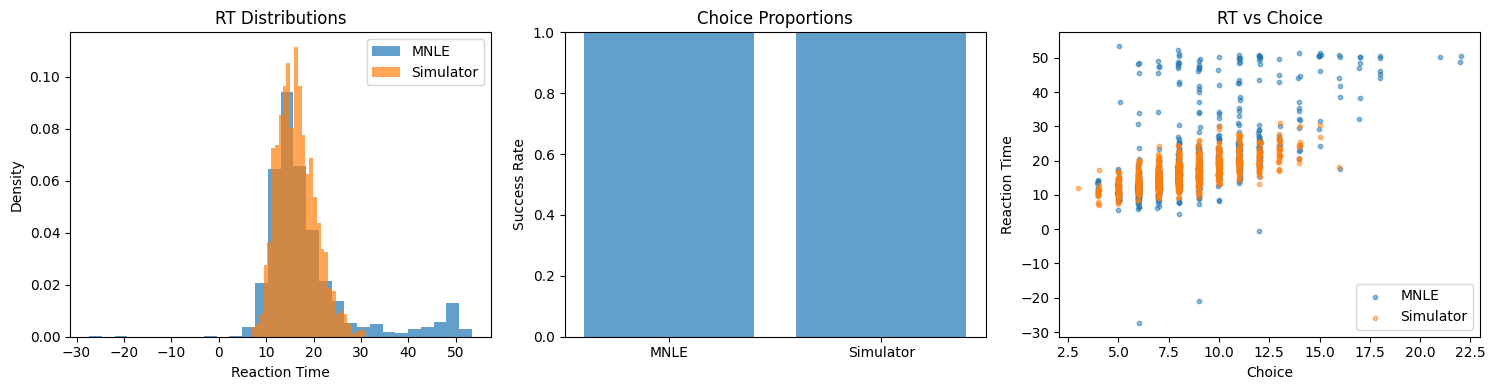

In [6]:
# Compare MNLE vs simulator
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RT distributions
axes[0].hist(synthetic_data[:, 0].numpy(), bins=30, alpha=0.7, label='MNLE', density=True)
axes[0].hist(real_data[:, 0].numpy(), bins=30, alpha=0.7, label='Simulator', density=True)
axes[0].set_xlabel('Reaction Time')
axes[0].set_ylabel('Density')
axes[0].set_title('RT Distributions')
axes[0].legend()

# Choice proportions
synth_success = synthetic_data[:, 1].mean()
real_success = real_data[:, 1].mean()
axes[1].bar(['MNLE', 'Simulator'], [synth_success, real_success], alpha=0.7)
axes[1].set_ylabel('Success Rate')
axes[1].set_title('Choice Proportions')
axes[1].set_ylim([0, 1])

# RT vs Choice scatter
axes[2].scatter(synthetic_data[:, 1] + np.random.normal(0, 0.02, 1000), 
                synthetic_data[:, 0], alpha=0.5, label='MNLE', s=10)
axes[2].scatter(real_data[:, 1] + np.random.normal(0, 0.02, 1000), 
                real_data[:, 0], alpha=0.5, label='Simulator', s=10)
axes[2].set_xlabel('Choice')
axes[2].set_ylabel('Reaction Time')
axes[2].set_title('RT vs Choice')
axes[2].legend()

plt.tight_layout()
plt.show()



In [7]:
## Generate posterior samples using MCMC
print("\n" + "="*50)
print("POSTERIOR INFERENCE")
print("="*50)

# Configure MCMC parameters
params = MCMCPosteriorParameters(
    method="slice_np_vectorized",
    num_chains=10,
    thin=10,
    warmup_steps=100,
    init_strategy="proposal"
)

# Build posterior
print("Building posterior...")
mnle_posterior = trainer.build_posterior(prior=prior, posterior_parameters=params)

# Sample from posterior given observed data
num_samples = 1000
print(f"Sampling {num_samples} posterior samples...")
mnle_samples = mnle_posterior.sample((num_samples,), x=x_o, show_progress_bars=False)

print(f"Posterior samples shape: {mnle_samples.shape}")

## Analysis of results
print("\n" + "="*50)
print("RESULTS ANALYSIS")
print("="*50)

# Compare true vs estimated parameters
true_params = theta_o[0].numpy()
posterior_mean = mnle_samples.mean(0).numpy()
posterior_std = mnle_samples.std(0).numpy()

param_names = ['Drift', 'Threshold', 'Starting Point']

print("Parameter Recovery:")
print("-" * 40)
for i, name in enumerate(param_names):
    print(f"{name:12}: True={true_params[i]:.3f}, Est={posterior_mean[i]:.3f}±{posterior_std[i]:.3f}")




POSTERIOR INFERENCE
Building posterior...
Sampling 1000 posterior samples...
Posterior samples shape: torch.Size([1000, 3])

RESULTS ANALYSIS
Parameter Recovery:
----------------------------------------
Drift       : True=0.765, Est=0.739±0.101
Threshold   : True=4.660, Est=4.108±0.511
Starting Point: True=0.766, Est=0.511±0.457


/var/folders/rv/bpj1qnwx5lz32q8rr9jxs07h0000gp/T/ipykernel_9242/1311556520.py:2: DeprecationWarning: you passed deprecated arguments **kwargs: ['kde_offdiag', 'kde_diag', 'contour_offdiag', 'points_colors', 'points_offdiag'], use fig_kwargs instead. We continue calling the deprecated pairplot function
  fig, ax = pairplot([


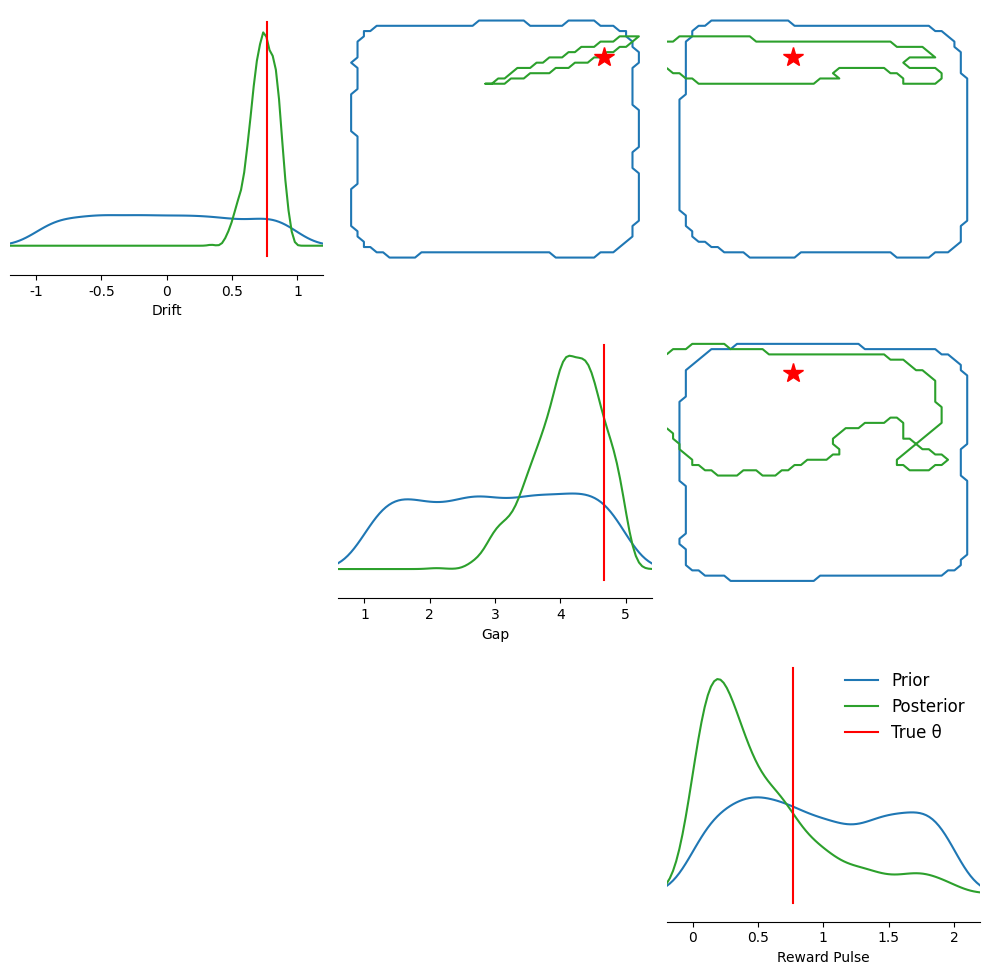

In [9]:
# Pairplot of prior vs posterior
fig, ax = pairplot([
    prior.sample((1000,)),
    mnle_samples,
], 
    points=theta_o, 
    diag="kde",
    upper="contour", 
    kde_offdiag=dict(bins=50),
    kde_diag=dict(bins=100),
    contour_offdiag=dict(levels=[0.95]),
    points_colors=["red"], 
    points_offdiag=dict(marker="*", markersize=15), 
    labels=["Drift", "Gap", "Reward Pulse"],
)

plt.sca(ax[2, 2])
plt.legend(["Prior", "Posterior", "True θ"], 
           frameon=False, 
           fontsize=12)

plt.tight_layout()
plt.show()



In [10]:
## Inference with new data (without retraining)
print("\n" + "="*50)
print("NEW DATA INFERENCE")
print("="*50)

# Generate new observed data with different number of trials
torch.manual_seed(123)  # Different seed for new "experiment"
new_theta_o = prior.sample((1,))
new_num_trials = 15  # Different number of trials

print(f"New true parameters: {new_theta_o[0]}")
x_o_new = torch.stack([simulator(new_theta_o[0]) for _ in range(new_num_trials)])

# Run inference without retraining MNLE
new_samples = mnle_posterior.sample((num_samples,), x=x_o_new, show_progress_bars=False)

# Compare results
new_posterior_mean = new_samples.mean(0).numpy()
new_true_params = new_theta_o[0].numpy()

print("\nNew Parameter Recovery:")
print("-" * 40)
for i, name in enumerate(param_names):
    print(f"{name:12}: True={new_true_params[i]:.3f}, Est={new_posterior_mean[i]:.3f}±{new_samples.std(0)[i]:.3f}")

print("\nMNLE training is complete! The neural network can now be used for")
print("inference on new data without retraining.")


NEW DATA INFERENCE
New true parameters: tensor([-0.4078,  3.0662,  0.5033])

New Parameter Recovery:
----------------------------------------
Drift       : True=-0.408, Est=-0.604±0.258
Threshold   : True=3.066, Est=3.336±1.093
Starting Point: True=0.503, Est=1.365±0.477

MNLE training is complete! The neural network can now be used for
inference on new data without retraining.
